<a href="https://colab.research.google.com/github/akshat-mishra-ds/Integrated-Retail-Analytics-for-Store-Optimization/blob/main/Retail_Analytics_for_Store_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Integrated Retail Analytics for Store Optimization

##### **Project Type**    - Advanced Machine Learning
##### **Contribution**    - Individual
##### **Submitted by -** Akshat Mishra

# **Project Summary -**

The **Integrated Retail Analytics for Store Optimization** project is a data-driven initiative focused on improving performance of retail store through advanced analytics and machine learning techniques.Now-a-days competitive retail environment , businesses should move from using traditional reporting to adopt intelligent systems that can discover hidden patterns and predict future demand and support strategic decision-making.

This project aims to bridge that gap by transforming raw retail data into actionable business insights.


**Dataset**

In this project we use three interconnected datasets contains sales-level, store-level, and external feature information.

- The sales dataset contains weekly sales for different stores and department along with holiday indicator.
- The store dataset provides details such as store type and size, which helps in understanding structural differences across locations.
- The features dataset contains external factors such as Temperature, Fuel price, Markdowns, Consumer Price Index, and unemployment rate.

By using these datasets, the project identifies both internal business dynamics and external economic influences which affects sales performance.

**Key Objectives:**
- Analyze Past Retail data to identify trends, patterns, and anomalies.
- Using Machine Learning and Time-Series models to Forecast weekly
sales for stores and Departments.
- Identifies the impact of external economic and environmental factors on sales.
- Divide stores and departments based on performance and behavioral patterns.
- Give Actionable insights to improve marketing strategies and planning inventory.

**Business Impact:**
- Helps Retailers to make strategic decisions by providing insights into sales trends and demand fluctuations.
- Helps in optimizing inventory levels, reducing stockouts and overstock situations.
- By understanding store segments and external influences, businesses can design targeted marketing campaigns and pricing strategies.
- Anomaly detection helps in capturing irregular patterns that may indicate issues or chances for growth.

# **GitHub Link -**

https://github.com/akshat-mishra-ds/Integrated-Retail-Analytics-for-Store-Optimization

# **Problem Statement**


The objective of this project is to analyze retail sales data to:

- Identify anomalies in sales patterns
- Understand seasonal and holiday impacts
- Segment stores based on performance
- Forecast future sales
- Analyze external economic factors
- Develop actionable business strategies

The final goal is to improve inventory planning,
marketing effectiveness, and store performance.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [20]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Anomaly Detection
from sklearn.ensemble import IsolationForest

# Forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model Evaluation
from sklearn.metrics import mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# ============================================================
# Load Dataset Files
# ============================================================

sales = pd.read_csv("/content/drive/MyDrive/Specialization projects/Retail Analytics for store optimization/Retail Datsets/sales data-set.csv")

features = pd.read_csv("/content/drive/MyDrive/Specialization projects/Retail Analytics for store optimization/Retail Datsets/Features data set.csv")

stores = pd.read_csv("/content/drive/MyDrive/Specialization projects/Retail Analytics for store optimization/Retail Datsets/stores data-set.csv")


### Dataset First View

In [23]:
# Display first 5 records

sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [24]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [25]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


### Dataset Rows & Columns count

In [26]:
# Dataset Rows & Columns count
print("Sales Dataset - \nRows & Columns :", sales.shape)

Sales Dataset - 
Rows & Columns : (421570, 5)


In [27]:
print("Features Dataset - \nRows & Columns :", features.shape)

Features Dataset - 
Rows & Columns : (8190, 12)


In [28]:
print("Stores Dataset - \nRows & Columns :", stores.shape)

Stores Dataset - 
Rows & Columns : (45, 3)


### Dataset Information

In [29]:
# Dataset Info
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [30]:
sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,421570.0,22.200546,12.785297,1.00,11.00,22.00,33.0000,45.00
Dept,421570.0,44.260317,30.492054,1.00,18.00,37.00,74.0000,99.00
Weekly_Sales,421570.0,15981.258123,22711.183519,-4988.94,2079.65,7612.03,20205.8525,693099.36


In [31]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [32]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,8190.0,23.000000,12.987966,1.000,12.000000,23.000000,34.000000,45.000000
Temperature,8190.0,59.356198,18.678607,-7.290,45.902500,60.710000,73.880000,101.950000
Fuel_Price,8190.0,3.405992,0.431337,2.472,3.041000,3.513000,3.743000,4.468000
MarkDown1,4032.0,7032.371786,9262.747448,-2781.450,1577.532500,4743.580000,8923.310000,103184.980000
MarkDown2,2921.0,3384.176594,8793.583016,-265.760,68.880000,364.570000,2153.350000,104519.540000
MarkDown3,3613.0,1760.100180,11276.462208,-179.260,6.600000,36.260000,163.150000,149483.310000
MarkDown4,3464.0,3292.935886,6792.329861,0.220,304.687500,1176.425000,3310.007500,67474.850000
MarkDown5,4050.0,4132.216422,13086.690278,-185.170,1440.827500,2727.135000,4832.555000,771448.100000
CPI,7605.0,172.460809,39.738346,126.064,132.364839,182.764003,213.932412,228.976456
Unemployment,7605.0,7.826821,1.877259,3.684,6.634000,7.806000,8.567000,14.313000


In [33]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [34]:
stores.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,45.0,23.0,13.133926,1.0,12.0,23.0,34.0,45.0
Size,45.0,130287.6,63825.271991,34875.0,70713.0,126512.0,202307.0,219622.0


#### Duplicate Values

In [35]:
# Dataset Duplicate Value Count
print(sales.duplicated().sum())
print(features.duplicated().sum())
print(stores.duplicated().sum())

0
0
0


#### Missing Values/Null Values

In [36]:
# Missing Values/Null Values Count

sales.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


In [37]:
features.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585


In [38]:
stores.isnull().sum()

,0
Store,0
Type,0
Size,0


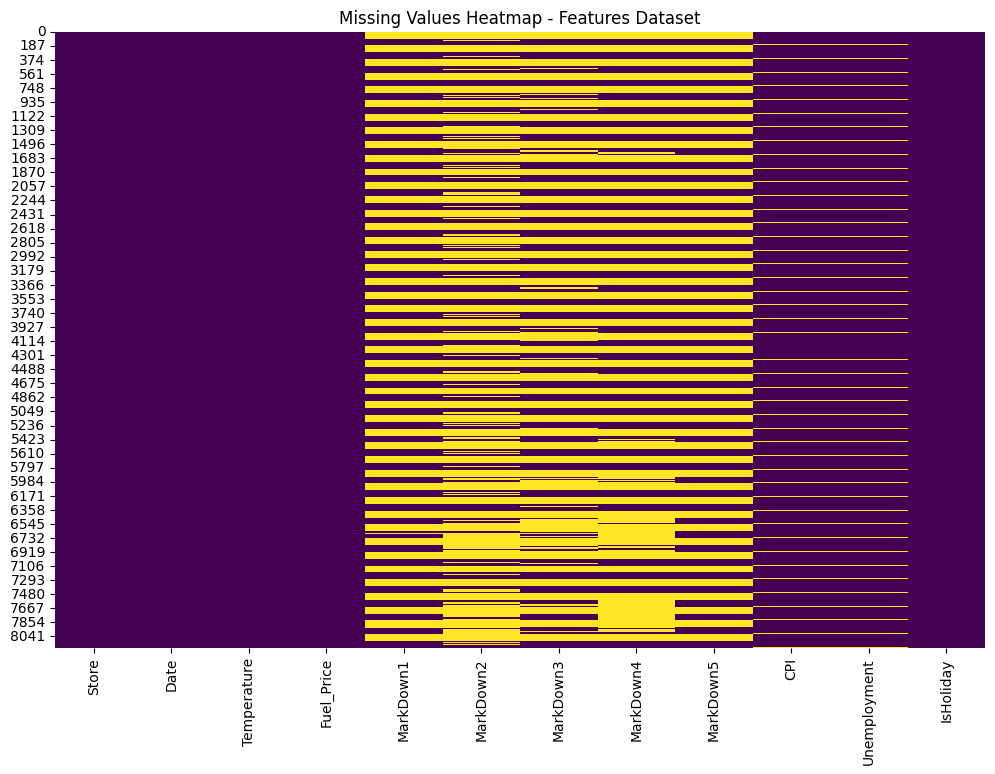

In [40]:
# Visualizing the missing values
plt.figure(figsize = (12,8))

sns.heatmap(features.isnull(), cbar = False, cmap = 'viridis')
plt.title('Missing Values Heatmap - Features Dataset')
plt.show()

### What did you know about your dataset?

- The sales dataset is large (421570 records) and contains weekly sales at store and department level, making it suitable for detailed analysis and forecasting.

- The stores dataset is small and clean, providing static information like store type and size, which can be useful for segmentation and feature engineering.

- The features dataset includes external factors such as temperature, fuel price, CPI, unemployment, and markdowns, which are important for understanding sales behavior.

- No duplicate records are present in any dataset, so no duplicate handling is required.

- No missing values are found in sales and stores datasets, indicating clean core data.

- Significant missing values are present in markdown columns (MarkDown1–5), which likely represent weeks with no promotions and need proper handling.

- The Date column is in object format and needs to be converted to datetime for time-based analysis.

Overall the datasets are well-structured and rich, combining internal sales data with external economic indicators, making them highly suitable for advanced analytics, anomaly detection, and demand forecasting.


## ***2. Understanding Your Variables***

In [50]:
# Sales Dataset Columns
print(f"Columns in Sales Dataset :\n{sales.columns}")

Columns in Sales Dataset :
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')


In [51]:
# Stores Dataset Columns
print(f"Columns in Stores Dataset :\n{stores.columns}")

Columns in Stores Dataset :
Index(['Store', 'Type', 'Size'], dtype='object')


In [52]:
# Dataset Columns
print(f"Columns in Features Dataset :\n{features.columns}")

Columns in Features Dataset :
Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='object')


### Variables Description

**Sales Dataset:**
- **Store:** Unique identifier for each store
- **Dept:** Department number within the store
- **Date:** Week of sales
- **Weekly_Sales:** Total sales for the given store and department in a week (Target Variable)
- **IsHoliday:** Boolean indicating whether the week includes a holiday
---
**Stores Dataset:**
- **Store:** Unique store identifier
- **Type:** Store category (A, B, C)
- **Size:** Size of the store (area)
---
**Features Dataset:**
- **Store:** Store identifier
- **Date:** Week of observation
- **Temperature:** Average temperature during the week
- **Fuel_Price:** Cost of fuel in the region
- **MarkDown1–5:** Promotional markdown values (can be null if no promotion)
- **CPI:** Consumer Price Index (economic indicator)
- **Unemployment:** Unemployment rate
- **IsHoliday:** Indicates if the week is a holiday

### Check Unique Values for each variable.

In [57]:
# ============================================================
# Check number of unique values in each column
# ============================================================

print("Sales Dataset unique values - \n")
for col in sales.columns:
    print(f"{col} : {sales[col].nunique()}")

Sales Dataset unique values - 

Store : 45
Dept : 81
Date : 143
Weekly_Sales : 359464
IsHoliday : 2


In [58]:
print("Stores Dataset unique values - \n")
for col in stores.columns:
    print(f"{col} : {stores[col].nunique()}")

Stores Dataset unique values - 

Store : 45
Type : 3
Size : 40


In [59]:
print("Features Dataset unique values - \n")
for col in features.columns:
    print(f"{col} : {features[col].nunique()}")

Features Dataset unique values - 

Store : 45
Date : 182
Temperature : 4178
Fuel_Price : 1011
MarkDown1 : 4023
MarkDown2 : 2715
MarkDown3 : 2885
MarkDown4 : 3405
MarkDown5 : 4045
CPI : 2505
Unemployment : 404
IsHoliday : 2


## 3. ***Data Wrangling***

### Data Wrangling Code

In [64]:
# ===========================================================
# Convert Date columns in both datasets
# ===========================================================

sales['Date'] = pd.to_datetime(
    sales['Date'],
    format='%d/%m/%Y'
)

features['Date'] = pd.to_datetime(
    features['Date'],
    format='%d/%m/%Y'
)

In [68]:
# ============================================================
# Merge Sales and Features Dataset
# ============================================================

df = pd.merge(
    sales,
    features,
    on=['Store','Date','IsHoliday'],
    how='left'
)

# ============================================================
# Merge Store Information
# ============================================================

df = pd.merge(
    df,
    stores,
    on='Store',
    how='left'
)

In [70]:
# ============================================================
# Handling Missing values in markdown columns.
# ============================================================

markdown_cols = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

for col in markdown_cols:
    df[col] = df[col].fillna(0)

### What all manipulations have you done and insights you found?

Manipulations Done:
- Converted Date column into datetime format for proper time-based analysis.
- Merged sales, features, and stores datasets using Store and Date.
- Handled missing values in MarkDown columns by replacing them with 0, assuming no promotions during those weeks.

Insights Found:

- A large number of missing values were present in MarkDown columns, indicating that promotional activities are not frequent across all stores and weeks.
- No missing values were found in core variables like Weekly_Sales, Temperature, CPI, and Unemployment, ensuring data reliability.
- The dataset now combines sales performance with external and store-level factors, making it suitable for deeper analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Weekly Sales Distribution

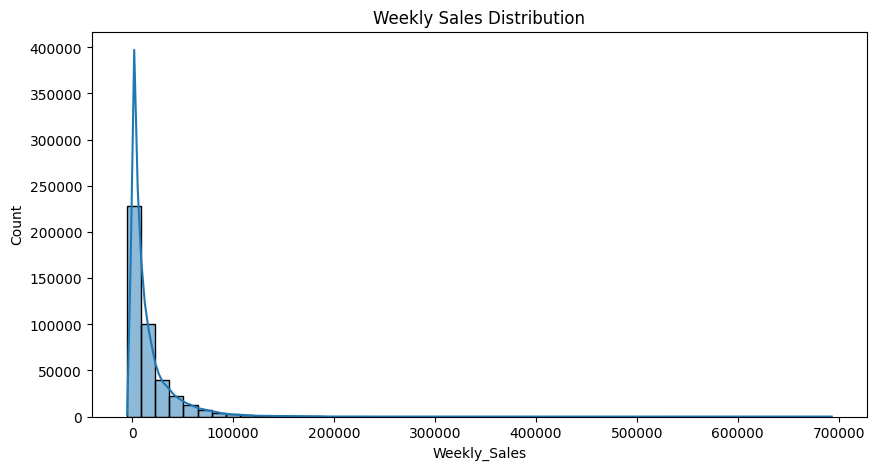

In [86]:
# Chart - 1 - Weekly Sales Distribution
plt.figure(figsize=(10,5))

sns.histplot(df['Weekly_Sales'], bins=50, kde=True)

plt.title("Weekly Sales Distribution")

plt.show()

##### 1. Why did you pick the specific chart?

To understand how sales values are distributed.

##### 2. What is/are the insight(s) found from the chart?

Most sales are low, with very few extremely high values (right-skewed distribution).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight can help us to identify weeks in which there are higher sales and with this info the company can plan the inventory accordingly.

#### Chart - 2 : Sales per Month

Text(0.5, 1.0, 'Sum of weekly sales per month')

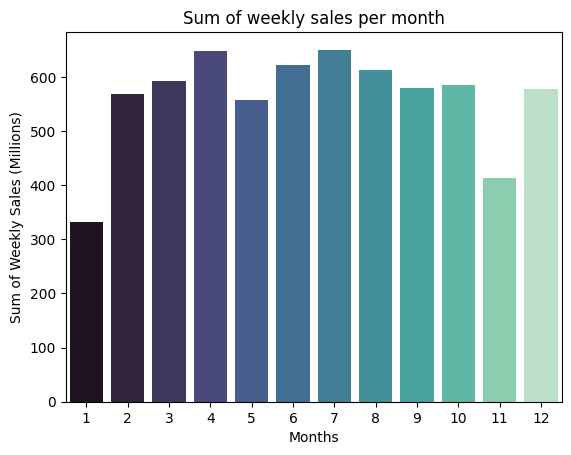

In [104]:
# Chart - 2 visualization code

# Sum of weekly sales each month, across the years
monthly_sales = df.groupby(df.Date.dt.month)['Weekly_Sales'].sum()/1000000
sns.barplot(x = monthly_sales.index, y = monthly_sales.values, palette='mako')
plt.xlabel('Months')
plt.ylabel('Sum of Weekly Sales (Millions)')
plt.title("Sum of weekly sales per month")

##### 1. Why did you pick the specific chart?

To identify, which month the business is getting higher sales.

##### 2. What is/are the insight(s) found from the chart?

- April and july are the months with highest sales followed by june, august, september and october.
- November shows a dip in purchasing activity, likely because customers are waiting for upcoming sales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can help business create better selling strategies and also can help the business plan the offers and promotions period.

#### Chart - 3 : Sales by Year

Text(0.5, 0, 'Years')

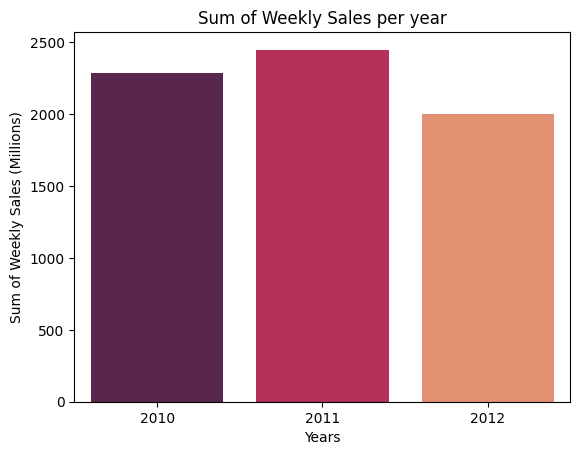

In [88]:
# Chart - 3 visualization code
yearly_sales = df.groupby(df.Date.dt.year)['Weekly_Sales'].sum()/1000000
sns.barplot(x = yearly_sales.index, y = yearly_sales.values, palette = 'rocket')
plt.title("Sum of Weekly Sales per year")
plt.ylabel("Sum of Weekly Sales (Millions)")
plt.xlabel("Years")


##### 1. Why did you pick the specific chart?

To see which year has the highest sales.

##### 2. What is/are the insight(s) found from the chart?

In our data, 2011 is the year in which the company made the highest sales followed bu 2010 and 2012.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can help the business to identify the reason behind the higher sales and can take necessary actions to increase the sales in coming years.

#### Chart - 4 : Store type Distribution

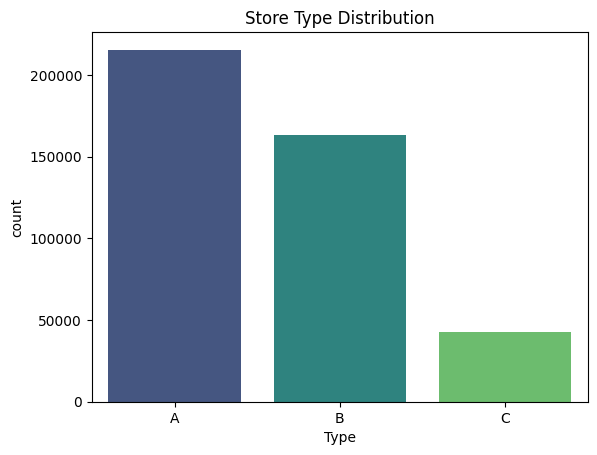

In [83]:
# Chart - 4 visualization code

sns.countplot(x='Type', data=df, palette='viridis')
plt.title("Store Type Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

To see distribution of store categories.

##### 2. What is/are the insight(s) found from the chart?

Type A stores are the most, followed by B, while C stores are very few.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight can help in comparing performance by store type.

#### Chart - 5 : Fule Price Distribution

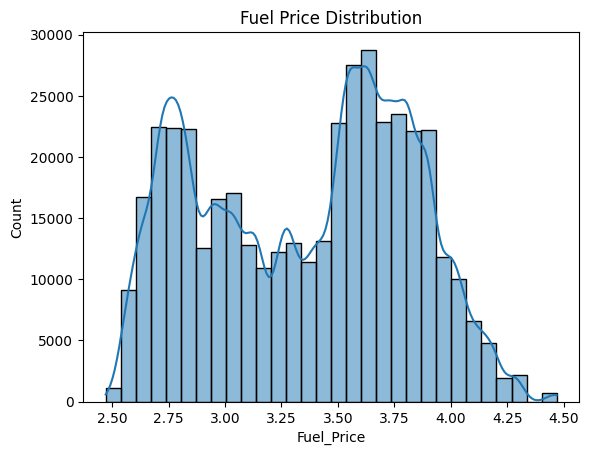

In [94]:
# Chart - 5 visualization code
# Fuel Price Distribution

sns.histplot(df['Fuel_Price'], bins=30, kde=True)
plt.title("Fuel Price Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Fuel prices show moderate variation with some clustering.

##### 2. What is/are the insight(s) found from the chart?

Fuel price shows moderate variations with some clustering.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight can help understand the impact of fuel price on customer spending.

#### Chart - 6 : Sales by store type & holiday

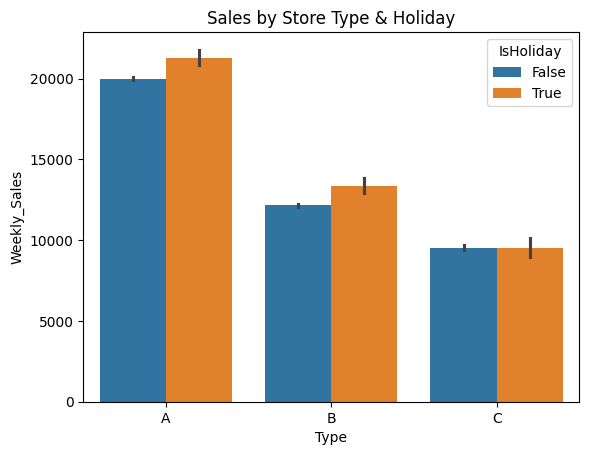

In [105]:
# Chart - 6 visualization code

sns.barplot(x='Type', y='Weekly_Sales', hue='IsHoliday', data=df)
plt.title("Sales by Store Type & Holiday")
plt.show()

##### 1. Why did you pick the specific chart?

To observe the impact of store type and holiday on sales.

##### 2. What is/are the insight(s) found from the chart?

Store A & B gets higher sales on holidays but store C gets equal sales on holiday and non-holidays.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can help create targetted promotions.

#### Chart - 7 : Average Unemployment Rate across Time

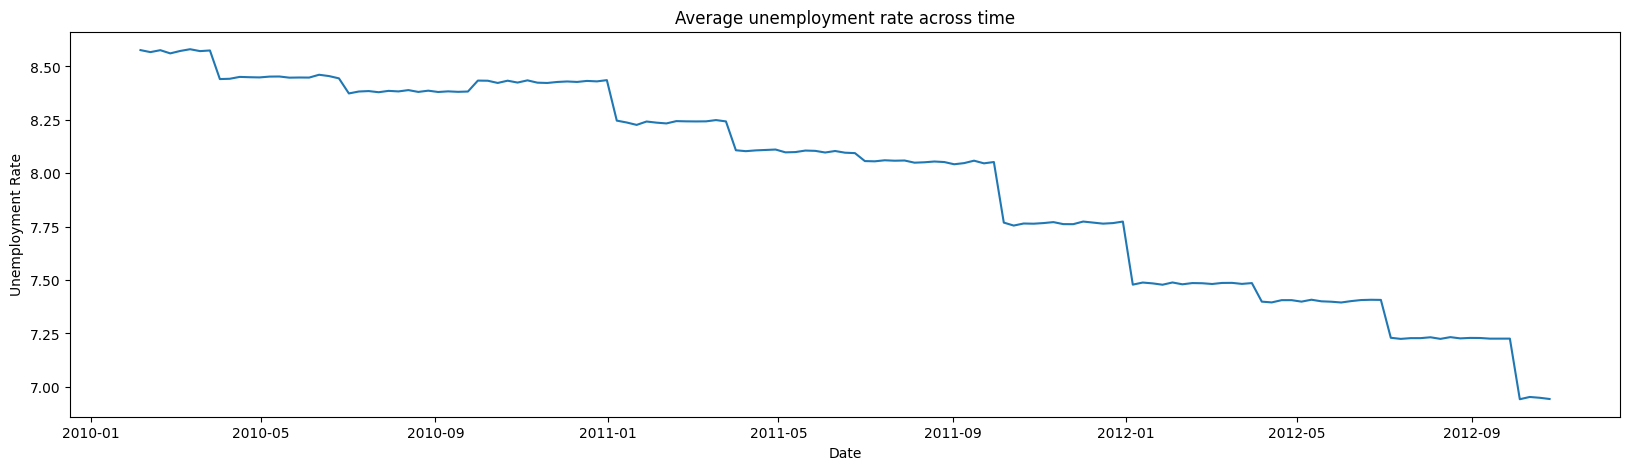

In [112]:
# Chart - 7 : Unemployment across time

# Average rate of unemployment each date for all the different outlets
unemp_rate = df.groupby(by = ['Date'], as_index= False)['Unemployment'].mean()


plt.figure(figsize = (20,5))
plt.plot(unemp_rate.Date, unemp_rate.Unemployment)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.title("Average unemployment rate across time")
plt.show()

##### 1. Why did you pick the specific chart?

To check for the average unemployment rate over time.

##### 2. What is/are the insight(s) found from the chart?

Over the period from January 2010 to December 2012, we have noted a gradual decrease in the unemployment rate. This result in improving the purchasing power of the customer.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can help us understand the purchasing power of the customers.

#### Chart - 8 : Sum of Sales across departments

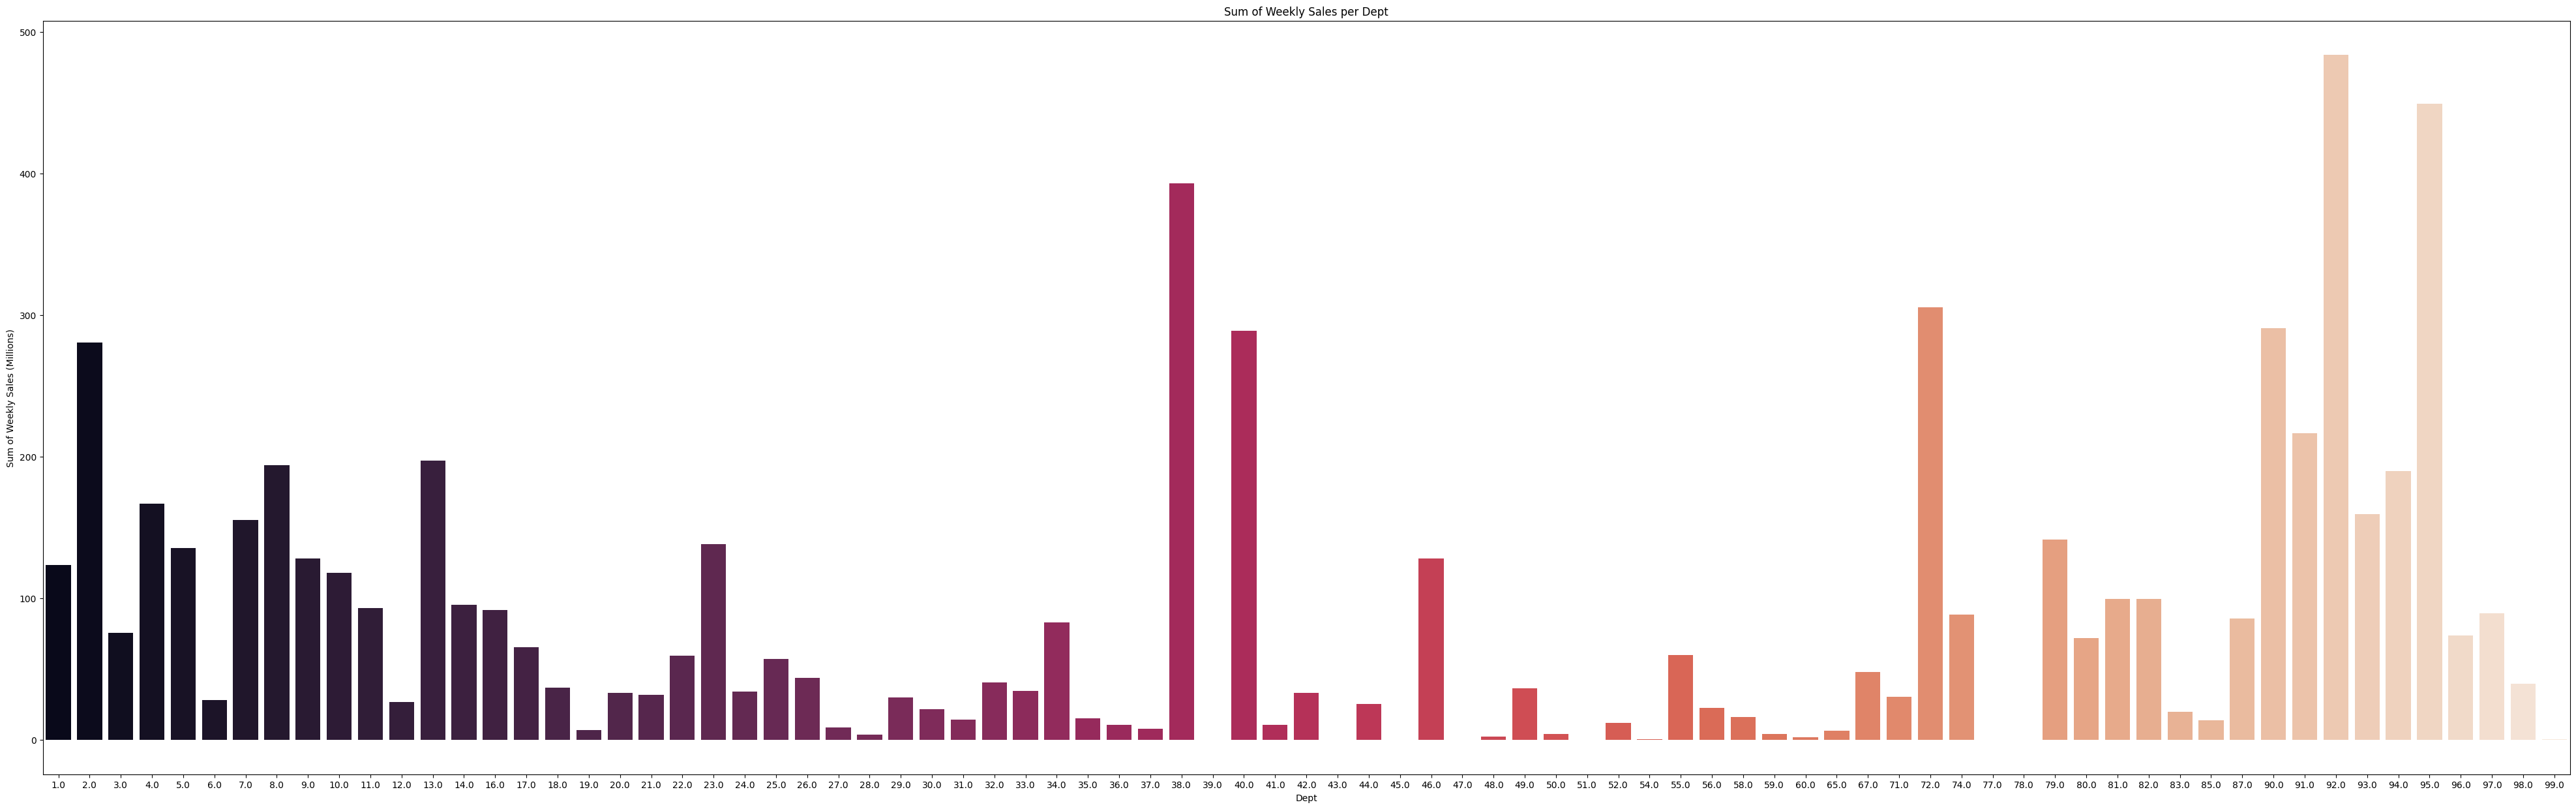

In [124]:
# Chart - 8 visualization code

# Sum of weekly sales across Department
dept_sales = df.groupby(by = ['Dept'], as_index= False)['Weekly_Sales'].sum()
dept_sales['Weekly_Sales'] = dept_sales['Weekly_Sales']/1000000
plt.figure(figsize=(50,15))
sns.barplot(x = dept_sales.Dept, y = dept_sales.Weekly_Sales , data = dept_sales, palette ='rocket')
plt.xlabel('Dept')
plt.ylabel('Sum of Weekly Sales (Millions)')
plt.title('Sum of Weekly Sales per Dept')
plt.show()

##### 1. Why did you pick the specific chart?

To understand sales by departments.

##### 2. What is/are the insight(s) found from the chart?

Department 38, 92,95 have the highest sales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps indentifying the weak department to take necessary actions in terms of promotion or planning to increase sales.

#### Chart - 9 : Correlation Heatmap

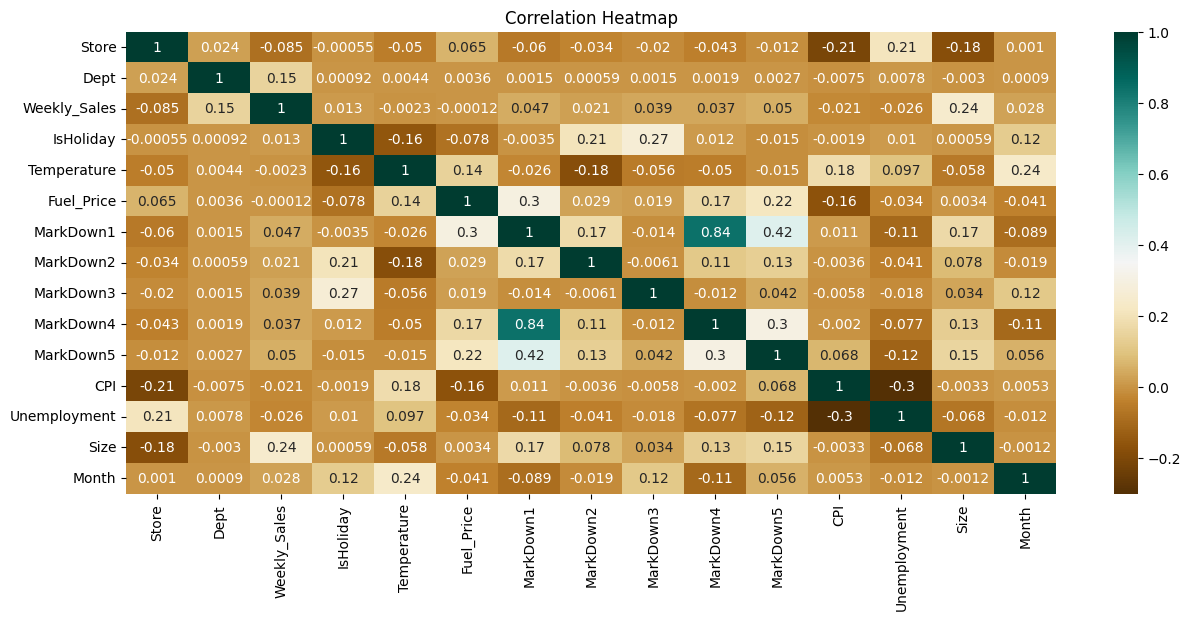

In [121]:
# Correlation Heatmap

plt.figure(figsize=(15,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='BrBG')
plt.title("Correlation Heatmap")
plt.show()


##### 1. Why did you pick the specific chart?

To check the correlation between the variables.

##### 2. What is/are the insight(s) found from the chart?

Some variables are weakly correlated with sales.

#### Chart - 10 : Pair Plot

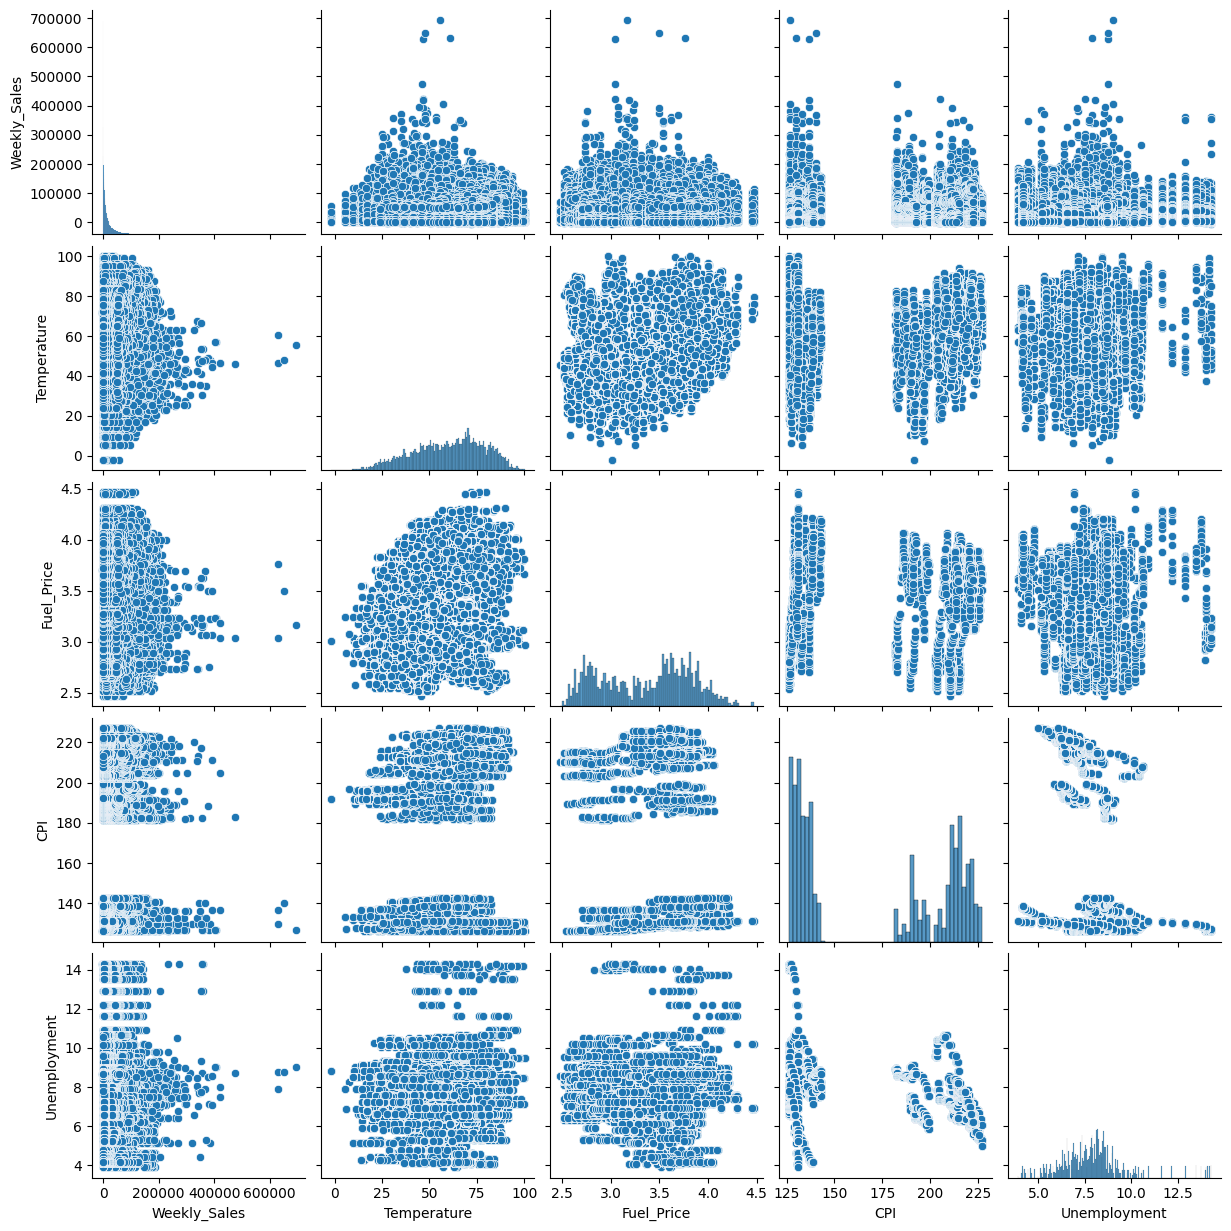

In [108]:
# Pair Plot

sns.pairplot(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']])
plt.show()

##### 1. Why did you pick the specific chart?

To visualize multiple relationships.

##### 2. What is/are the insight(s) found from the chart?

Most variables show weak linear relationships.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***